# MLP do Zero - Experimentos no MNIST

Este notebook treina e avalia um MLP implementado manualmente com NumPy.

**Estrutura:**
1. Carregamento e pré-processamento do MNIST
2. Experimento 1 — rede menor (128-64)
3. Experimento 2 — rede maior (256-128)
4. Comparação dos resultados
5. Matriz de confusão
6. Visualização de exemplos errados

In [3]:
import sys
sys.path.insert(0, '..')  # permite importar a pasta mlp/

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

print('NumPy:', np.__version__)

NumPy: 2.4.6


## 1. Carregamento e pré-processamento do MNIST

In [4]:
from sklearn.datasets import fetch_openml

print("Baixando MNIST")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='liac-arff')

X = mnist.data.astype('float32') / 255.0  # normaliza para [0, 1]
y = mnist.target.astype(int)

# Os primeiros 60000 são treino, os últimos 10000 são teste
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Versão 2D para visualização das imagens
X_train_raw = (X_train * 255).reshape(-1, 28, 28).astype('uint8')
X_test_raw  = (X_test  * 255).reshape(-1, 28, 28).astype('uint8')

print(f'Treino: {X_train.shape}, Teste: {X_test.shape}')
print(f'Classes: {np.unique(y_train)}')

Baixando MNIST (pode demorar um pouco na primeira vez)...
Treino: (60000, 784), Teste: (10000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]


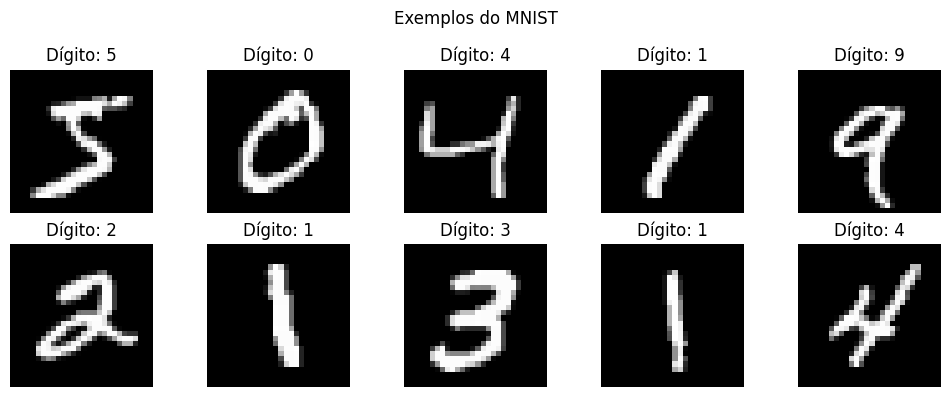

In [5]:
# Visualiza alguns exemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i], cmap='gray')
    ax.set_title(f'Dígito: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Exemplos do MNIST')
plt.tight_layout()
plt.savefig('../results/exemplos_mnist.png')
plt.show()

## 2. Experimento 1 — Rede Menor: [784 → 128 → 64 → 10]

Configuração mais simples para servir como linha de base.

In [6]:
from mlp.network import MLP

np.random.seed(42)

modelo1 = MLP(
    layer_sizes=[784, 128, 64, 10],
    learning_rate=0.1
)

print('=== Experimento 1: rede [784, 128, 64, 10] | lr=0.1 ===')
hist1 = modelo1.train(
    X_train, y_train,
    X_test, y_test,
    epochs=20,
    batch_size=64
)

acc1 = modelo1.evaluate(X_test, y_test)
print(f'\nAcurácia final no teste: {acc1*100:.2f}%')

=== Experimento 1: rede [784, 128, 64, 10] | lr=0.1 ===
Época  1/20 | Loss: 0.3317 | Treino: 0.9498 | Teste: 0.9471
Época  2/20 | Loss: 0.1496 | Treino: 0.9631 | Teste: 0.9594
Época  3/20 | Loss: 0.1080 | Treino: 0.9698 | Teste: 0.9636
Época  4/20 | Loss: 0.0856 | Treino: 0.9739 | Teste: 0.9641
Época  5/20 | Loss: 0.0706 | Treino: 0.9832 | Teste: 0.9707
Época  6/20 | Loss: 0.0582 | Treino: 0.9869 | Teste: 0.9737
Época  7/20 | Loss: 0.0492 | Treino: 0.9886 | Teste: 0.9754
Época  8/20 | Loss: 0.0418 | Treino: 0.9917 | Teste: 0.9750
Época  9/20 | Loss: 0.0355 | Treino: 0.9840 | Teste: 0.9716
Época 10/20 | Loss: 0.0313 | Treino: 0.9933 | Teste: 0.9779
Época 11/20 | Loss: 0.0257 | Treino: 0.9942 | Teste: 0.9770
Época 12/20 | Loss: 0.0215 | Treino: 0.9938 | Teste: 0.9758
Época 13/20 | Loss: 0.0186 | Treino: 0.9974 | Teste: 0.9784
Época 14/20 | Loss: 0.0156 | Treino: 0.9972 | Teste: 0.9765
Época 15/20 | Loss: 0.0132 | Treino: 0.9980 | Teste: 0.9765
Época 16/20 | Loss: 0.0107 | Treino: 0.9981 

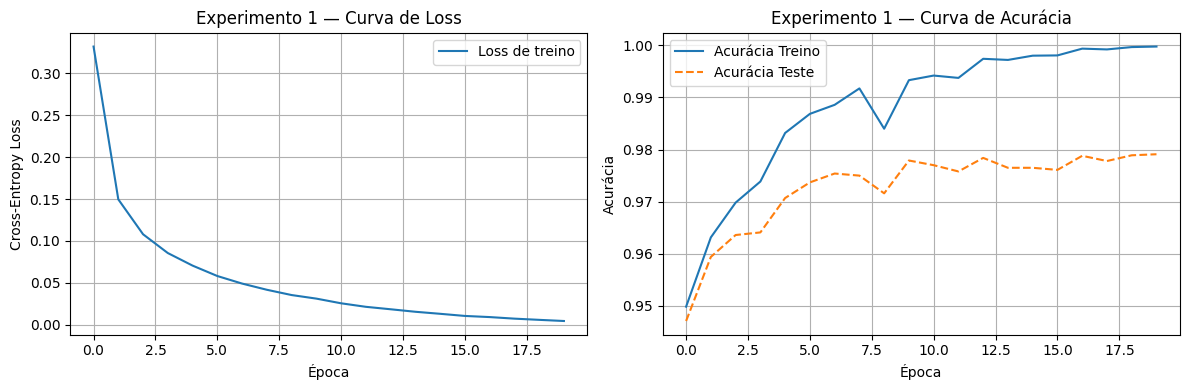

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist1['train_loss'], label='Loss de treino')
ax1.set_xlabel('Época')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Experimento 1 — Curva de Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(hist1['train_acc'], label='Acurácia Treino')
ax2.plot(hist1['val_acc'], label='Acurácia Teste', linestyle='--')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_title('Experimento 1 — Curva de Acurácia')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('../results/experimento1_curvas.png')
plt.show()

## 3. Experimento 2 — Rede Maior: [784 → 256 → 128 → 10]

Mais neurônios = mais capacidade de aprendizado. Vamos ver se melhora o resultado.

In [8]:
np.random.seed(42)

modelo2 = MLP(
    layer_sizes=[784, 256, 128, 10],
    learning_rate=0.05
)

print('=== Experimento 2: rede [784, 256, 128, 10] | lr=0.05 ===')
hist2 = modelo2.train(
    X_train, y_train,
    X_test, y_test,
    epochs=20,
    batch_size=64
)

acc2 = modelo2.evaluate(X_test, y_test)
print(f'\nAcurácia final no teste: {acc2*100:.2f}%')

=== Experimento 2: rede [784, 256, 128, 10] | lr=0.05 ===
Época  1/20 | Loss: 0.3908 | Treino: 0.9284 | Teste: 0.9295
Época  2/20 | Loss: 0.1927 | Treino: 0.9554 | Teste: 0.9531
Época  3/20 | Loss: 0.1437 | Treino: 0.9644 | Teste: 0.9590
Época  4/20 | Loss: 0.1151 | Treino: 0.9723 | Teste: 0.9662
Época  5/20 | Loss: 0.0952 | Treino: 0.9776 | Teste: 0.9708
Época  6/20 | Loss: 0.0808 | Treino: 0.9762 | Teste: 0.9681
Época  7/20 | Loss: 0.0692 | Treino: 0.9826 | Teste: 0.9704
Época  8/20 | Loss: 0.0602 | Treino: 0.9852 | Teste: 0.9754
Época  9/20 | Loss: 0.0526 | Treino: 0.9845 | Teste: 0.9711
Época 10/20 | Loss: 0.0453 | Treino: 0.9887 | Teste: 0.9762
Época 11/20 | Loss: 0.0404 | Treino: 0.9912 | Teste: 0.9772
Época 12/20 | Loss: 0.0353 | Treino: 0.9901 | Teste: 0.9750
Época 13/20 | Loss: 0.0310 | Treino: 0.9944 | Teste: 0.9784
Época 14/20 | Loss: 0.0276 | Treino: 0.9950 | Teste: 0.9786
Época 15/20 | Loss: 0.0241 | Treino: 0.9962 | Teste: 0.9781
Época 16/20 | Loss: 0.0213 | Treino: 0.996

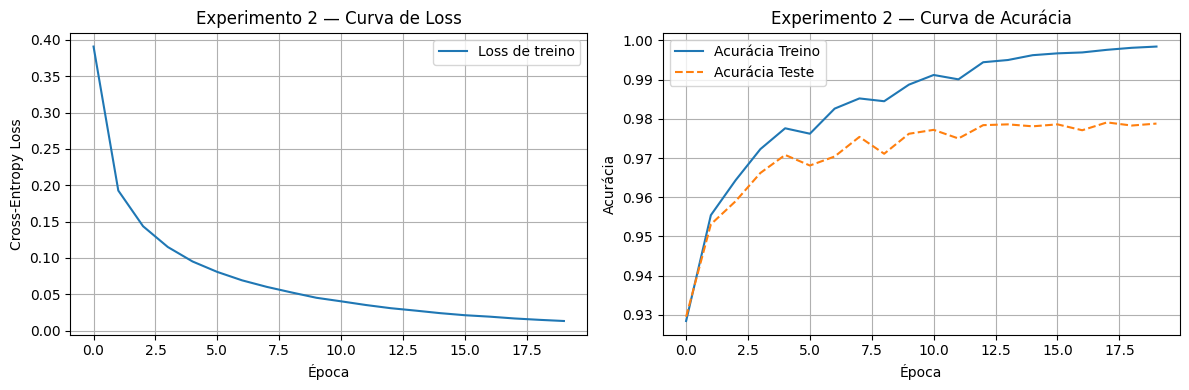

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist2['train_loss'], label='Loss de treino')
ax1.set_xlabel('Época')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Experimento 2 — Curva de Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(hist2['train_acc'], label='Acurácia Treino')
ax2.plot(hist2['val_acc'], label='Acurácia Teste', linestyle='--')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_title('Experimento 2 — Curva de Acurácia')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('../results/experimento2_curvas.png')
plt.show()

## 4. Comparação dos Experimentos

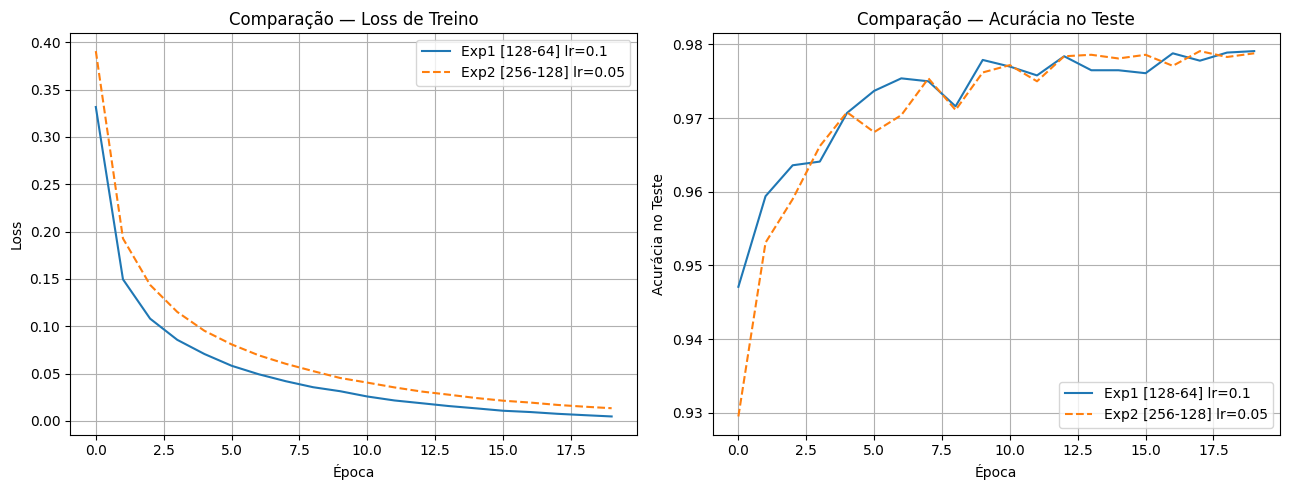


=== Tabela Comparativa ===
Configuração                        |  Acurácia Teste
-------------------------------------------------------
Exp1: [784,128,64,10] lr=0.1        |          97.91%
Exp2: [784,256,128,10] lr=0.05      |          97.88%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist1['train_loss'], label='Exp1 [128-64] lr=0.1')
axes[0].plot(hist2['train_loss'], label='Exp2 [256-128] lr=0.05', linestyle='--')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Comparação — Loss de Treino')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist1['val_acc'], label='Exp1 [128-64] lr=0.1')
axes[1].plot(hist2['val_acc'], label='Exp2 [256-128] lr=0.05', linestyle='--')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia no Teste')
axes[1].set_title('Comparação — Acurácia no Teste')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../results/comparacao_experimentos.png')
plt.show()

print('\n=== Tabela Comparativa ===')
print(f'{"Configuração":<35} | {"Acurácia Teste":>15}')
print('-' * 55)
print(f'{"Exp1: [784,128,64,10] lr=0.1":<35} | {acc1*100:>14.2f}%')
print(f'{"Exp2: [784,256,128,10] lr=0.05":<35} | {acc2*100:>14.2f}%')

## 5. Matriz de Confusão (melhor modelo)

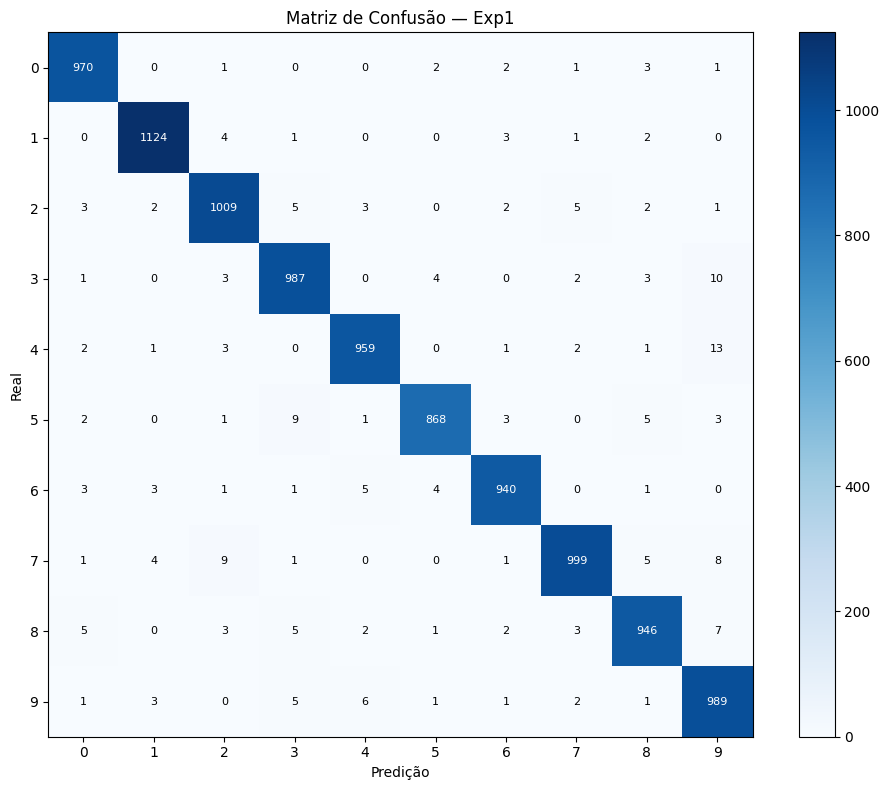


Dígitos com mais erros (linhas com menor diagonal):
  Dígito 0: 99.0%
  Dígito 1: 99.0%
  Dígito 2: 97.8%
  Dígito 3: 97.7%
  Dígito 4: 97.7%
  Dígito 5: 97.3%
  Dígito 6: 98.1%
  Dígito 7: 97.2%
  Dígito 8: 97.1%
  Dígito 9: 98.0%


In [11]:
# Usa o modelo com melhor acurácia
melhor_modelo = modelo1 if acc1 >= acc2 else modelo2
nome_melhor = 'Exp1' if acc1 >= acc2 else 'Exp2'

y_pred = melhor_modelo.predict(X_test)

# Calcula a matriz de confusão manualmente
n_classes = 10
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(y_test, y_pred):
    conf_matrix[true][pred] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xlabel('Predição')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusão — {nome_melhor}')

for i in range(n_classes):
    for j in range(n_classes):
        color = 'white' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black'
        ax.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.savefig('../results/matriz_confusao.png')
plt.show()

print('\nDígitos com mais erros (linhas com menor diagonal):')
acuracias_por_classe = conf_matrix.diagonal() / conf_matrix.sum(axis=1)
for i, acc_c in enumerate(acuracias_por_classe):
    print(f'  Dígito {i}: {acc_c*100:.1f}%')

## 6. Visualizando Erros do Modelo

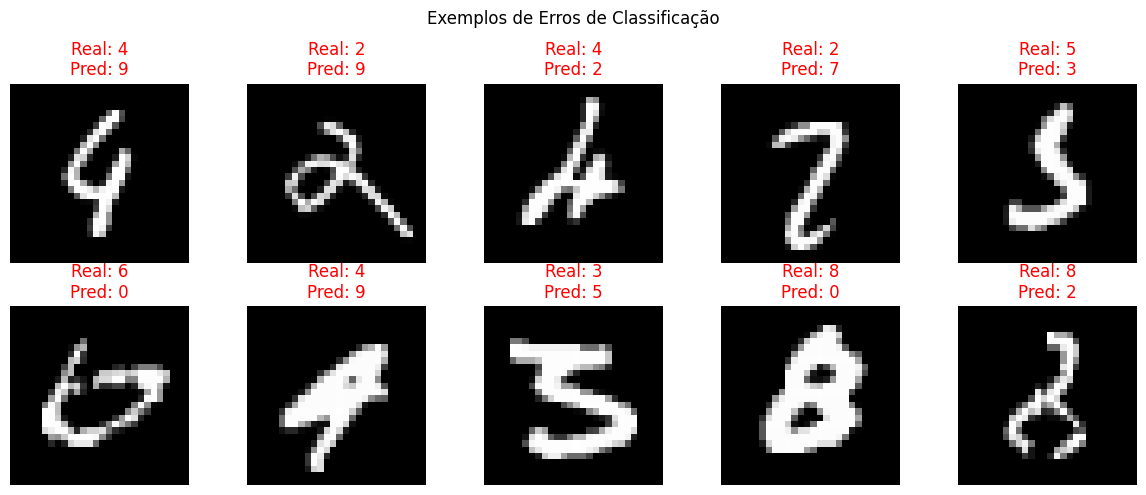

In [12]:
erros = np.where(y_pred != y_test)[0][:10]  # primeiros 10 erros

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flat, erros):
    ax.imshow(X_test_raw[idx], cmap='gray')
    ax.set_title(f'Real: {y_test[idx]}\nPred: {y_pred[idx]}', color='red')
    ax.axis('off')

plt.suptitle('Exemplos de Erros de Classificação')
plt.tight_layout()
plt.savefig('../results/erros_classificacao.png')
plt.show()